# Step 3: Data Augmentation

用 new_features（224 筆）訓練，對 hist_features（10487 筆）推估 BASS 參數（p、q、M、constant）。

- **方法 A**：KMeans Clustering（k=10）
- **方法 B**：KNN 距離加權（K=5）

以 test set（20%）的 MAE / RMSE 決定最終使用方法。

In [36]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [37]:
PROCESSED = Path('../data/processed')
OUTPUT    = Path('../data/output')
OUTPUT.mkdir(parents=True, exist_ok=True)

new_features  = pd.read_csv(PROCESSED / 'new_features.csv')
hist_features = pd.read_csv(PROCESSED / 'hist_features.csv')

print('new_features :', new_features.shape)
print('hist_features:', hist_features.shape)

new_features : (223, 60)
hist_features: (10373, 59)


## 1. 定義特徵欄位與資料切分

In [38]:
emb_cols    = [f'emb_{i:03d}' for i in range(32)]
target_cols = ['p_after4d', 'q_after4d', 'M_after4d', 'constant_after4d_time0_views']
out_cols    = ['p', 'q', 'M', 'constant']

# 只保留四個 target 都不為空的樣本，並做 log1p 壓縮極端值
labeled = new_features.dropna(subset=target_cols).reset_index(drop=True)
labeled[target_cols] = labeled[target_cols].apply(np.log1p)

train_df, test_df = train_test_split(labeled, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'labeled: {len(labeled)} 筆')
print(f'train  : {len(train_df)} 筆')
print(f'test   : {len(test_df)} 筆')

labeled: 223 筆
train  : 178 筆
test   : 45 筆


In [39]:
# LabelEncoder：fit 在三個資料集的聯集上，確保 hist/test 不會出現 unseen label
le = LabelEncoder()
all_labels = list(
    pd.concat([train_df['best_topic_labels'],
               test_df['best_topic_labels'],
               hist_features['best_topic_labels']])
    .dropna().unique()
) + ['unknown']
le.fit(all_labels)

num_extra = ['duration', 'AI業配判定']

def build_raw(df):
    d = df[emb_cols + num_extra].copy()
    d['best_topic_labels_enc'] = le.transform(
        df['best_topic_labels'].fillna('unknown')
    )
    return d

# 中位數和 StandardScaler 只在 train 上 fit（避免 leakage）
train_raw = build_raw(train_df)
medians   = train_raw.median()

scaler = StandardScaler()
scaler.fit(train_raw.fillna(medians))

def get_X(df):
    d = build_raw(df).fillna(medians)
    return scaler.transform(d)

X_train = get_X(train_df)
print(f'特徵維度：{X_train.shape[1]}  '
      f'（emb×32 + duration + AI業配判定 + best_topic_labels_enc）')

特徵維度：35  （emb×32 + duration + AI業配判定 + best_topic_labels_enc）


## 2. 方法 A：KMeans Clustering

In [40]:
K_CLUSTERS = 8

kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(X_train)

train_df = train_df.copy()
train_df['cluster'] = kmeans.labels_
cluster_means = train_df.groupby('cluster')[target_cols].mean()

def predict_kmeans(df):
    clusters = kmeans.predict(get_X(df))
    return cluster_means.loc[clusters].reset_index(drop=True)

test_pred_a = predict_kmeans(test_df)
print('方法 A 預測範例（前 3 筆）:')
print(test_pred_a.head(3))

方法 A 預測範例（前 3 筆）:
   p_after4d  q_after4d  M_after4d  constant_after4d_time0_views
0   0.085319   0.075308  13.262702                      9.996986
1   0.085319   0.075308  13.262702                      9.996986
2   0.085319   0.075308  13.262702                      9.996986


## 3. 方法 B：KNN 距離加權

In [41]:
K_NEIGHBORS = 5

knn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
knn.fit(X_train)

def predict_knn(df):
    distances, idx = knn.kneighbors(get_X(df))
    weights = 1.0 / (distances + 1e-8)
    weights = weights / weights.sum(axis=1, keepdims=True)
    preds = {}
    for col in target_cols:
        neighbor_vals = train_df[col].values[idx]  # (n, K)
        preds[col]    = (weights * neighbor_vals).sum(axis=1)
    return pd.DataFrame(preds)

test_pred_b = predict_knn(test_df)
print('方法 B 預測範例（前 3 筆）:')
print(test_pred_b.head(3))

方法 B 預測範例（前 3 筆）:
      p_after4d  q_after4d  M_after4d  constant_after4d_time0_views
0  8.495877e-02   0.057409  19.791718                     10.470564
1  6.239626e-02   0.136263  10.438343                      9.957237
2  6.159539e-07   0.024815  26.859802                     11.491891


## 4. 交叉驗證（Test Set 評估）

In [42]:
# target 已做 log1p，預測值也在 log scale，MAE/RMSE 直接在 log scale 下比較
rows = []
for col, label in zip(target_cols, out_cols):
    y = test_df[col].values
    rows.append({
        'target'  : label,
        'MAE_A'   : mean_absolute_error(y, test_pred_a[col]),
        'RMSE_A'  : np.sqrt(mean_squared_error(y, test_pred_a[col])),
        'MAE_B'   : mean_absolute_error(y, test_pred_b[col]),
        'RMSE_B'  : np.sqrt(mean_squared_error(y, test_pred_b[col])),
    })

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))

rmse_a_total = eval_df['RMSE_A'].sum()
rmse_b_total = eval_df['RMSE_B'].sum()
print(f'\nRMSE 總和（log scale）— 方法 A (KMeans): {rmse_a_total:.4f}')
print(f'RMSE 總和（log scale）— 方法 B (KNN)   : {rmse_b_total:.4f}')

  target    MAE_A    RMSE_A    MAE_B    RMSE_B
       p 0.070583  0.079054 0.064437  0.084761
       q 0.100695  0.148720 0.126534  0.187685
       M 7.217780 25.570856 7.251263 26.217918
constant 1.315627  2.005821 1.519371  2.358785

RMSE 總和（log scale）— 方法 A (KMeans): 27.8045
RMSE 總和（log scale）— 方法 B (KNN)   : 28.8491


## 5. 選擇最佳方法並輸出 augmented_hist.csv

In [43]:
if rmse_a_total <= rmse_b_total:
    best_method  = 'KMeans'
    hist_pred_df = predict_kmeans(hist_features)
else:
    best_method  = 'KNN'
    hist_pred_df = predict_knn(hist_features)

print(f'選用方法：{best_method}')

hist_pred_df = hist_pred_df.rename(columns=dict(zip(target_cols, out_cols)))

# log scale → 原始尺度
for col in out_cols:
    hist_pred_df[col] = np.expm1(hist_pred_df[col])

hist_pred_df.insert(0, 'reels_shortcode', hist_features['reels_shortcode'].values)
hist_pred_df['method_used'] = best_method

out_path = OUTPUT / 'augmented_hist.csv'
hist_pred_df.to_csv(out_path, index=False)
print(f'已儲存：{out_path}')
print(hist_pred_df.shape)
print(hist_pred_df.head())

選用方法：KMeans
已儲存：../data/output/augmented_hist.csv
(10373, 6)
  reels_shortcode         p         q              M      constant method_used
0     DPeT4BHExo-  0.089064  0.078217  575330.758312  21959.187888      KMeans
1     DPZEm_oExnd  0.089064  0.078217  575330.758312  21959.187888      KMeans
2     DLvRZSlTBzn  0.089064  0.078217  575330.758312  21959.187888      KMeans
3     DIvNtToTBL-  0.089064  0.078217  575330.758312  21959.187888      KMeans
4     Ciksu1-vDBo  0.089064  0.078217  575330.758312  21959.187888      KMeans


=== Cluster 大小 ===
cluster
0    171
1      1
2      1
3      1
4      1
5      1
6      1
7      1

=== 各 Cluster top 3 best_topic_labels ===
Cluster  0: ['香水', '健身', '美髮']
Cluster  1: ['食譜']
Cluster  2: ['飲料']
Cluster  3: ['台灣旅遊']
Cluster  4: ['香水']
Cluster  5: ['家庭']
Cluster  6: ['營養與保健']
Cluster  7: ['飲料']


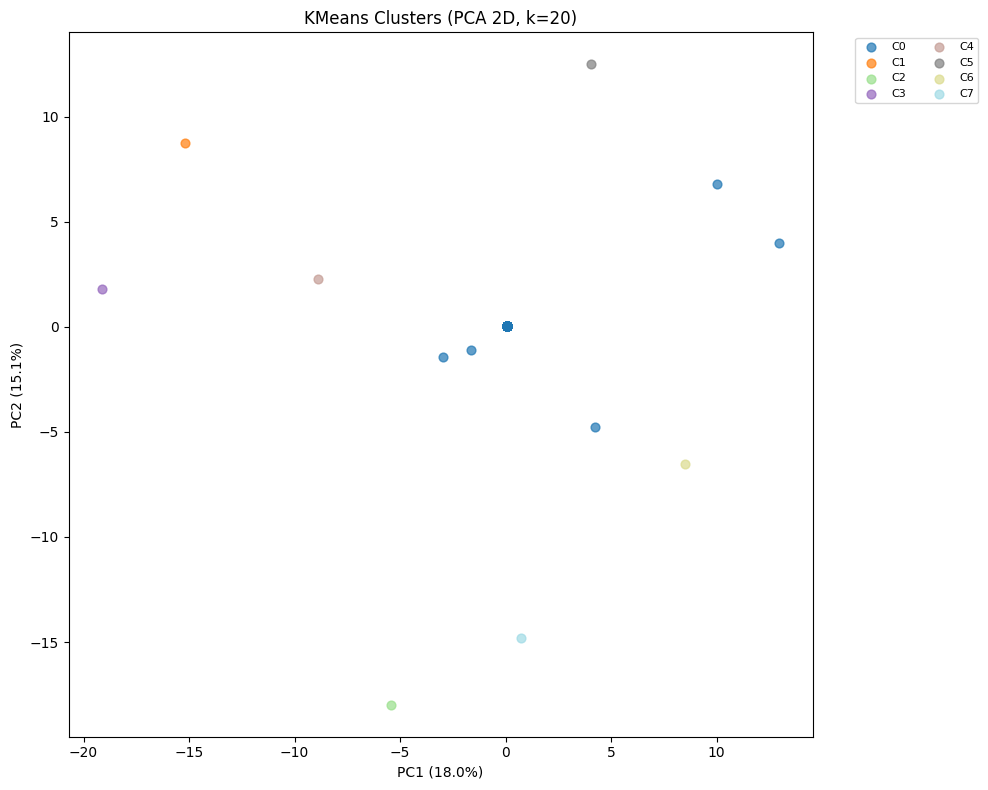

已儲存：../data/output/kmeans_cluster_viz.png

=== 特徵重要性 Top 10（cluster 間均值變異數）===
emb_016    21.837888
emb_004    21.633982
emb_012    21.511571
emb_022    20.979637
emb_018    19.636564
emb_021    19.580167
emb_024    19.347174
emb_030    18.989186
emb_015    18.814656
emb_002    18.395671


In [44]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA

feat_names = build_raw(train_df).columns.tolist()  # 35 維特徵名稱

# 1. Cluster 大小
print('=== Cluster 大小 ===')
print(train_df['cluster'].value_counts().sort_index().to_string())

# 2. 各 cluster 最常見的 best_topic_labels
print('\n=== 各 Cluster top 3 best_topic_labels ===')
for c in sorted(train_df['cluster'].unique()):
    top3 = (train_df[train_df['cluster'] == c]['best_topic_labels']
            .value_counts().head(3).index.tolist())
    print(f'Cluster {c:2d}: {top3}')

# 3. PCA 降維散點圖
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(10, 8))
colors  = cm.tab20(np.linspace(0, 1, K_CLUSTERS))
for c in range(K_CLUSTERS):
    mask = train_df['cluster'].values == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colors[c], label=f'C{c}', alpha=0.7, s=40)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('KMeans Clusters (PCA 2D, k=20)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
viz_path = OUTPUT / 'kmeans_cluster_viz.png'
plt.savefig(viz_path, dpi=150)
plt.show()
print(f'已儲存：{viz_path}')

# 4. 特徵重要性：cluster 間均值的變異數（越大代表該特徵對分群越有區別力）
feat_df = pd.DataFrame(X_train, columns=feat_names)
feat_df['cluster'] = train_df['cluster'].values
between_var = feat_df.groupby('cluster')[feat_names].mean().var()
top10 = between_var.sort_values(ascending=False).head(10)
print('\n=== 特徵重要性 Top 10（cluster 間均值變異數）===')
print(top10.to_string())